# Toroidal VAE

In [97]:
import os
import sys
mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [98]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [99]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders as dataloaders
import lib.models as models
import lib.trainer as trainer
import lib.utils as utils
import lib.models.utils.save_load_models as modelutils



### Set up and initialize data loader

In [100]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Euclidean VAE

### Dataloader

In [101]:
batch_size = 64

dataloader = dataloaders.load_fashion_mnist(batch_size)
train_loader, test_loader = dataloader

### Model

In [102]:
data_dim = 784
latent_dim = 4
sftbeta = 1
device = "cpu"
encoder_width = 128
encoder_depth = 2
decoder_width = 128
decoder_depth = 2

model_config = {'data_dim': data_dim, 'latent_dim': latent_dim, 'sftbeta': sftbeta, 'device': device,
                'encoder_width': encoder_width, 'encoder_depth': encoder_depth, 'decoder_width': decoder_width,
                'decoder_depth': decoder_depth}

toroidal_model = models.ToroidalVAE(model_config)

### Optimizer

In [103]:
learning_rate = 0.001

toroidal_optimizer = optim.Adam(toroidal_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [104]:
num_epochs = 1
log_interval = 100
device = "cpu"
recon_loss = "MSE"

trainer_config = {'num_epochs': num_epochs, 'log_interval': log_interval, 'device': device, 'recon_loss': recon_loss}

toroidal_history = trainer.MVAETrainer(toroidal_model, dataloader, toroidal_optimizer, trainer_config).train()

Trainer successfully initialized.
Training the toroidalVAE model.
Starting epoch 1/1
Epoch [1/1], Step [100/938], Loss: 4376.7505
Epoch [1/1], Step [200/938], Loss: 4485.3569


KeyboardInterrupt: 

### Visualization 

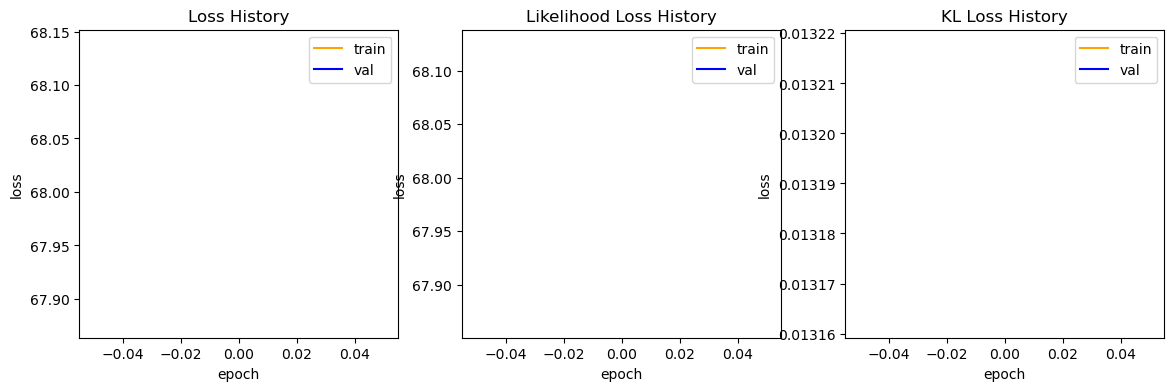

In [56]:
utils.show_training_history(toroidal_history)

### Save trained models

In [ ]:
#modelutils.save_model(toroidal_model, model_config)

### Load pretrained models

In [ ]:
#model = modelutils.load_model("gaussian_1740054584")
#model = toroidal_model

### Visualizing the latent space

In [ ]:
utils.plot_test_latents_on_torus(toroidal_model, test_loader, device)

#### Visualize reconstructed mnist images

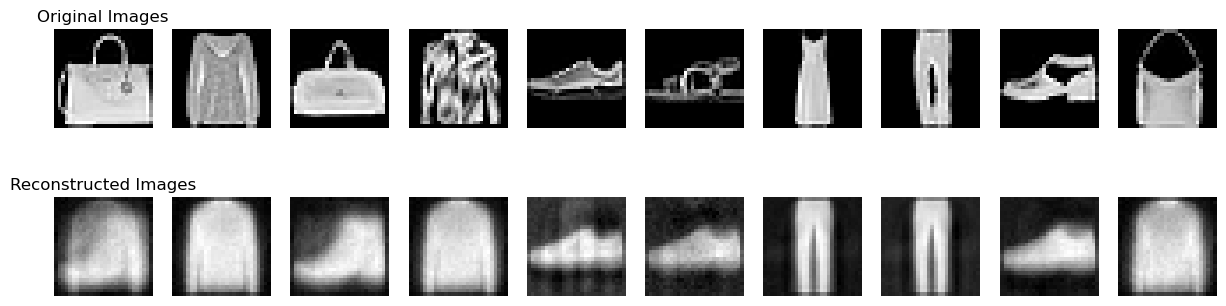

In [62]:
utils.show_recon_mnist(toroidal_model, test_loader, device)